<a href="https://colab.research.google.com/github/NganNguyenKha/DN-group-CMPE-132/blob/CNN/CNN_Thursday_AM_WebAttack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 #!/usr/bin/env python
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sklearn.preprocessing
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn import svm
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

In [ ]:
import missingno

In [ ]:
train_data = pd.read_csv('/content/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.train.csv')
test_data = pd.read_csv('/content/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.test.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/content/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.train.csv'

In [ ]:
train_data_df = pd.DataFrame(train_data)
print(train_data_df.shape)

In [ ]:
#train_data_df = train_data_df[['Duration','protocol_type', 'Service', 'Srv serror rate', 'Flag','src_bytes','dst_bytes', 'Dst host serror rate', 'Dst host srv serror rate', 'Dst host same src port rate', 'Label','Serror rate','Count','Dst host count']]
train_data_df = train_data_df[[' Destination Port', ' Flow Duration', ' Total Fwd Packets', 'Total Length of Fwd Packets', ' Label']]

In [ ]:
train_data_df.describe()

In [ ]:
train_data_df = train_data_df.dropna()

In [ ]:
print(train_data_df.columns)

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       'Total Length of Fwd Packets', ' Label'],
      dtype='object')


# Feature Engineering

# New Section

# New Section

In [ ]:
def encodify(dataframe, feature):
    encoder = LabelEncoder()
    encoder.fit(dataframe[feature])
    encoded_feature = encoder.transform(dataframe[feature])
    dataframe[feature] = encoded_feature

In [ ]:
discrete_feature_l = [' Destination Port', ' Flow Duration', ' Total Fwd Packets']
for feature in discrete_feature_l:
    encodify(train_data_df, feature)

# train-to-test split

In [ ]:
eighty_cut_n = math.ceil(train_data_df.shape[0] * 0.8)
print(eighty_cut_n)

13626


In [ ]:
train_data_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Label
0,12,9000,47,9668,BENIGN
1,12,9007,66,11364,BENIGN
2,0,10188,116,0,BENIGN
3,13,7788,8,2330,BENIGN
4,4,269,1,102,BENIGN


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
Scaler = StandardScaler()

In [ ]:
X = train_data_df.loc[:, [' Destination Port', ' Flow Duration', ' Total Fwd Packets', 'Total Length of Fwd Packets']]
y = train_data_df.loc[:, ' Label']

In [ ]:
X=Scaler.fit_transform(X)

In [ ]:
oversample = SMOTE()
X, y = oversample.fit_resample(X, y)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_data.shape
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 420)

In [ ]:
X_train.shape


(27230, 4)

In [ ]:
X_test.shape

(6808, 4)

In [ ]:
y_train.value_counts()

,count
Label,
Web Attack � Brute Force,13678
BENIGN,13552


<ipython-input-26-baa50a2511b9>:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  classes = pd.value_counts(y_train, sort = True)


Text(0, 0.5, 'Frequency')

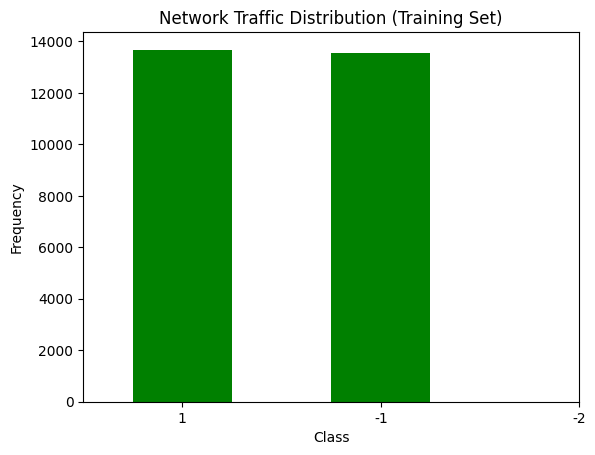

In [ ]:
label_l = ['1', '-1','-2']
classes = pd.value_counts(y_train, sort = True)
classes.plot(kind = 'bar', rot = 0, color = "green")
plt.title("Network Traffic Distribution (Training Set)")
plt.xticks(range(3), label_l)
plt.xlabel("Class")
plt.ylabel("Frequency")

In [ ]:
y_test.value_counts()

,count
Label,
BENIGN,3467
Web Attack � Brute Force,3341


<ipython-input-28-2b5c4e26709d>:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  classes = pd.value_counts(y_test , sort = True)


Text(0, 0.5, 'Frequency')

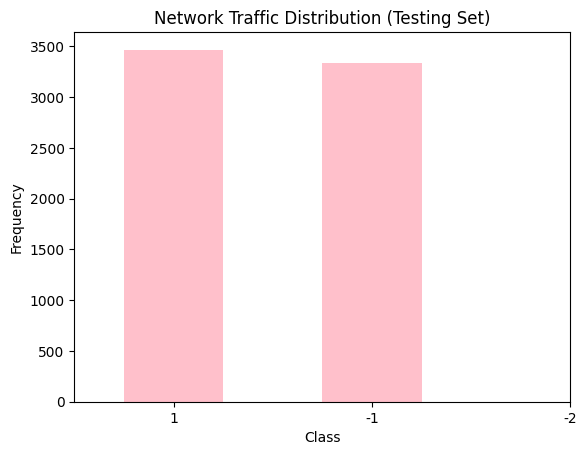

In [ ]:
labels = ['1', '-1','-2']
classes = pd.value_counts(y_test , sort = True)
classes.plot(kind = 'bar', rot = 0, color = "pink")
plt.title("Network Traffic Distribution (Testing Set)")
plt.xticks(range(3), labels)
plt.xlabel("Class")
plt.ylabel("Frequency")

## Modeling

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [ ]:
clf = MLPClassifier(solver='adam', alpha=1e-5,

                    hidden_layer_sizes=(5, 2), random_state=1, max_iter=1000)

In [ ]:
clf.fit(X, y)

MLPClassifier(alpha=1e-05, hidden_layer_sizes=(5, 2), max_iter=1000,
              random_state=1)

In [ ]:
pred_test_y = clf.predict(X_test)
print(pred_test_y)

['Web Attack � Brute Force' 'Web Attack � Brute Force'
 'Web Attack � Brute Force' ... 'Web Attack � Brute Force'
 'Web Attack � Brute Force' 'BENIGN']


In [ ]:
accuracy_score(y_test, pred_test_y)

0.8197708578143361

In [ ]:
cm = confusion_matrix(y_test, pred_test_y)

num_classes = cm.shape[0]
print(cm)

[[2384 1083]
 [ 144 3197]]


In [ ]:
if num_classes == 2:
    tn, fp, fn, tp = cm.ravel()  # Unpack for binary classification
    print(f"accuracy is {np.trace(cm) / np.sum(cm)}")
    print(f"precision is {tp / (tp + fp)}")
    print(f"recall is {tp / (tp + fn)}")
else:
    print(f"accuracy is {np.trace(cm) / np.sum(cm)}")  # Overall accuracy


accuracy is 0.8197708578143361
precision is 0.7469626168224299
recall is 0.9568991319964083


## SVM

https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

In [ ]:
nslkdd_svm_clf = svm.SVC(kernel = 'poly').fit(X_train, y_train)

In [ ]:
pred_test_y = nslkdd_svm_clf.predict(X_test)
print(pred_test_y)

['Web Attack � Brute Force' 'Web Attack � Brute Force'
 'Web Attack � Brute Force' ... 'BENIGN' 'Web Attack � Brute Force'
 'Web Attack � Brute Force']


In [ ]:
accuracy_score(y_test, pred_test_y)

0.8463572267920094

In [ ]:
confusion_matrix(y_test, pred_test_y)

array([[2806,  661],
       [ 385, 2956]])

In [ ]:
tn, fp, fn, tp = confusion_matrix(y_test, pred_test_y).ravel()
print(f"accuracy is {(tp +tn)/(tn+fp+fn+tp)}")
print(f"precision is {tp / (tp + fp)}")
print(f"recall is {tp / (tp + fn)}")

accuracy is 0.8463572267920094
precision is 0.8172518661874482
recall is 0.8847650404070637


In [ ]:
f1_score(y_test, pred_test_y, average='macro')

0.8462826048683639